In [104]:
#COSC 522 UTK
#Project 2
#Student Name: Dylan Shaffer

In [105]:
#load in data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

#Show fewer digits to improve readability
np.set_printoptions(precision=3, suppress=True)


In [106]:
dataset = pd.read_csv("ndtv_data_final.csv")
print(dataset.columns)

Index(['Unnamed: 0', 'Name', 'Brand', 'Model', 'Battery capacity (mAh)',
       'Screen size (inches)', 'Touchscreen', 'Resolution x', 'Resolution y',
       'Processor', 'RAM (MB)', 'Internal storage (GB)', 'Rear camera',
       'Front camera', 'Operating system', 'Wi-Fi', 'Bluetooth', 'GPS',
       'Number of SIMs', '3G', '4G/ LTE', 'Price'],
      dtype='str')


In [107]:
dataset.tail()

,Unnamed: 0,Name,Brand,Model,Battery capacity (mAh),Screen size (inches),Touchscreen,Resolution x,Resolution y,Processor,...,Rear camera,Front camera,Operating system,Wi-Fi,Bluetooth,GPS,Number of SIMs,3G,4G/ LTE,Price
1354,1354,Intex Aqua A2,Intex,Aqua A2,1500,4.0,Yes,480,800,4,...,5.0,0.3,Android,Yes,Yes,Yes,2,Yes,No,2599
1355,1355,Videocon Infinium Z51 Nova+,Videocon,Infinium Z51 Nova+,2000,5.0,Yes,480,854,4,...,8.0,5.0,Android,Yes,Yes,Yes,2,Yes,No,2940
1356,1356,Intex Aqua Y4,Intex,Aqua Y4,1700,4.5,Yes,480,854,2,...,5.0,2.0,Android,Yes,Yes,No,2,Yes,No,2999
1357,1357,iBall Andi4 B20,iBall,Andi4 B20,1250,4.0,Yes,480,800,1,...,2.0,0.3,Android,Yes,Yes,Yes,2,Yes,No,2498
1358,1358,iBall Andi Avonte 5,iBall,Andi Avonte 5,2150,5.0,Yes,480,854,4,...,8.0,0.0,Android,Yes,Yes,Yes,2,Yes,No,3999


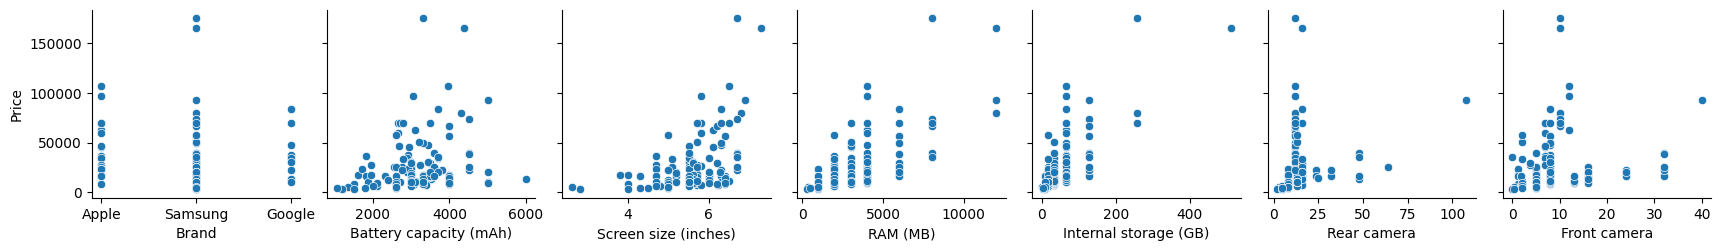

In [108]:
# Pairplot to show initial data
# Filtering brands for readability in pairplot
brands_to_include = ['Apple', 'Samsung', 'Google']

filtered_train = dataset[dataset['Brand'].isin(brands_to_include)]

pp = sns.pairplot(data=filtered_train,
                  x_vars=['Brand','Battery capacity (mAh)','Screen size (inches)','RAM (MB)','Internal storage (GB)','Rear camera','Front camera'],
                  y_vars=['Price'])

In [109]:
# Split data into training, validation, and test sets

# Features to use:
# Brand, Battery capacity (mAh), Screen size (inches), RAM (MB), Internal storage (GB), Rear camera, Front camera, Price

# Split will be 60/20/20
# Shuffle the dataset
shuffled = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Calculate split indices
n = len(shuffled)
train_end = int(0.6 * n)
val_end = int(0.8 * n)

# Split using iloc
train_data = shuffled.iloc[:train_end]
validate_data = shuffled.iloc[train_end:val_end]
test_data = shuffled.iloc[val_end:]

In [110]:
# Train dataset based on aforementioned features

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

# Features to use
feature_cols = [
    'Brand',
    'Battery capacity (mAh)',
    'Screen size (inches)',
    'RAM (MB)',
    'Internal storage (GB)',
    'Rear camera',
    'Front camera'
]

# Define numeric columns for normalization in preprocessing
numeric_cols = [
    'Battery capacity (mAh)',
    'Screen size (inches)',
    'RAM (MB)',
    'Internal storage (GB)',
    'Rear camera',
    'Front camera'
]

target_col = 'Price'

# Select only the relevant columns
train_features = train_data[feature_cols]
train_labels = train_data[target_col]

val_features = validate_data[feature_cols]
val_labels = validate_data[target_col]

test_features = test_data[feature_cols]
test_labels = test_data[target_col]

# One-Hot Encode the Brand column and normalize numeric features
preprocessor = ColumnTransformer(transformers=[
    ('brand_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Brand']),
    ('scaler', StandardScaler(), numeric_cols)
])

In [111]:
# Below two cells build the model pipelines and train them

In [112]:
# Overtrained model (no early stopping)
overtrained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SGDRegressor(max_iter=1000, random_state=42))
])

# Train
overtrained.fit(train_features, train_labels)

# Evaluate
print("Overtrained Train and Test Scores:\n")
print(overtrained.score(train_features, train_labels))
print(overtrained.score(test_features, test_labels))
print("\n")

Overtrained Train and Test Scores:

0.6248566621047018
0.5667987699261878




In [113]:
# Final model (with early stopping)
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SGDRegressor(max_iter=1000, early_stopping=True, 
                               validation_fraction=0.2, random_state=42))
])

# Train
final_model.fit(train_features, train_labels)

print("Final Model Train and Test Scores:\n")
print(final_model.score(train_features, train_labels))
print(final_model.score(test_features, test_labels))
print(f"Stopped at epoch: {final_model.named_steps['regressor'].n_iter_}")

Final Model Train and Test Scores:

0.5838083015319451
0.5487406005295881
Stopped at epoch: 41


In [114]:
# Performance metrics
from sklearn.metrics import mean_absolute_error

pred = final_model.predict(test_features)
mae = mean_absolute_error(test_labels, pred)
print(f"Test MAE: {mae}")

Test MAE: 4806.457376676749
